### Foreground comparison

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.signal import savgol_filter
import os
import scipy.constants as cst
import json
import pandas
import csv

In [2]:
fgfolder = '../data/'

In [20]:
fginfo_file = '../data/fgds_info.json'
with open(fginfo_file, 'r') as file:
    data = file.read()
fg_info = json.loads(data)

## kSZ

Text(0.5, 1.0, 'Total kSZ')

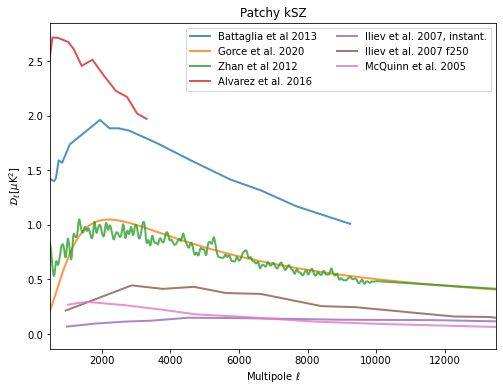

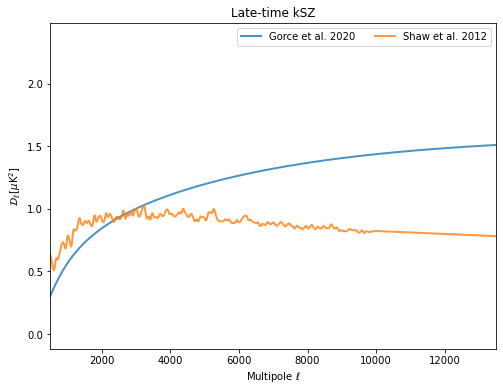

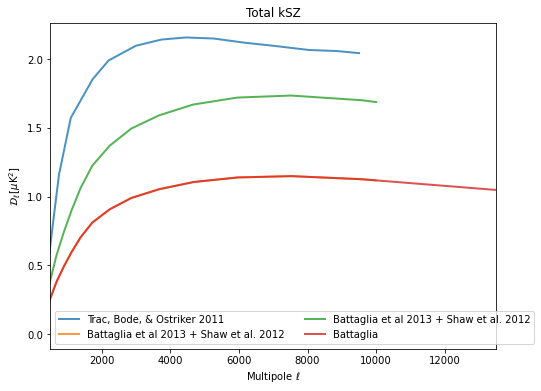

In [21]:
fig1, ax1 = plt.subplots(1, 1, figsize=(8, 6))
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 6))
fig3, ax3 = plt.subplots(1, 1, figsize=(8, 6))
nksz_temp = 0
ksz_keys = []
for k in fg_info.keys():
    if fg_info[k]['type'] == 'kSZ':
        ksz_keys.append(k)
        label = f"{fg_info[k]['authors']}"# {fg_info[k]['reference']}"
        try:
            if fg_info[k]['filetype'] in ['.dat', '.txt']:
                ells, cls = np.loadtxt(fgfolder+k, unpack=True)
                # print(cls.shape)
            elif fg_info[k]['filetype'] in ['.csv']:
                # print(k)
                data = pandas.read_csv(fgfolder+k)
                ells, cls = data.values.T
            if fg_info[k]['typebis'] == 'Patchy kSZ':
                ax1.plot(ells, cls, label=label, alpha=.8, lw=2.)
            elif fg_info[k]['typebis'] == 'Total kSZ':
                ax3.plot(ells, cls, label=label, alpha=.8, lw=2.)            
            else:
                ax2.plot(ells, cls, label=label, alpha=.8, lw=2.)
            nksz_temp += 1
        except OSError:
            print(f'{k} not found.')
for ax in [ax1, ax2, ax3]:
    ax.legend(ncol=2)
    ax.set_ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_xlim(500, 13500)
ax1.set_title('Patchy kSZ')
ax2.set_title('Late-time kSZ')
ax3.set_title('Total kSZ')

In [22]:
print(f'{nksz_temp} kSZ templates.')

13 kSZ templates.


dl_ksz_tbo.dat
9500 9500.0
485 484.48275862068965
{'authors': 'Trac, Bode, & Ostriker 2011', 'comments': 'homoegeneous reionisation at zre = 10', 'extrapolated': False, 'filetype': '.dat', 'freq': None, 'lmax': 9500, 'lmin': 485, 'reference': 'https://ui.adsabs.harvard.edu/abs/2011ApJ...727...94T/abstract', 'type': 'kSZ', 'typebis': 'Total kSZ', 'used_in': None, 'website': None, 'from': 'simulation', 'normalised': 0}


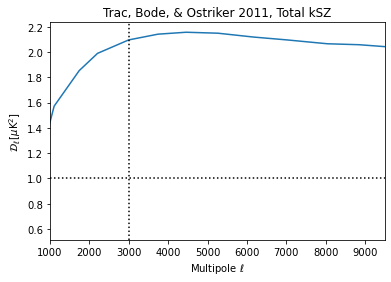

In [6]:
i = 0
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
plt.xlim(1000, 9500)
# plt.ylim(0, 15)
print(fg_info[k])
plt.axvline(3000, color='k', ls=':')
plt.axhline(1., color='k', ls=':')

dl_ksz_150_bat_norm3000.dat
10000 10000.0
2 2.0
{'authors': 'Battaglia et al 2013 + Shaw et al. 2012', 'comments': 'Unidentified, possibly Battaglia et al 2013 + Shaw et al. 2012 but does not really look like it.', 'extrapolated': False, 'filetype': '.dat', 'freq': None, 'lmax': 10000, 'lmin': 2, 'reference': 'https://ui.adsabs.harvard.edu/abs/2013ApJ...776...83B/abstract', 'type': 'kSZ', 'typebis': 'Total kSZ', 'from': 'simulations', 'used_in': 'SPT', 'website': None, 'normalised': 3000}


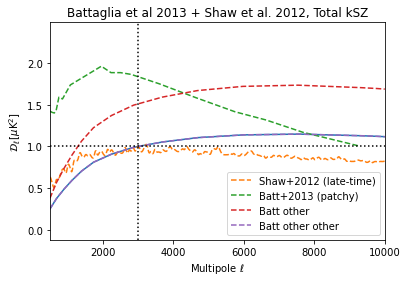

In [7]:
i = 1
k = ksz_keys[i]
print(k)

if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T

plt.figure()
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
plt.xlim(500, 10000)
# plt.ylim(0, 15)
# plt.xscale('log')
print(fg_info[k])

ells1, cls1 = np.loadtxt(fgfolder+'dl_ksz_CSFplusPATCHY_13sep2011_norm1_fake25000.txt', unpack=True)
plt.plot(ells1, cls1, ls='--', label='Shaw+2012 (late-time)')

ells2, cls2 = np.loadtxt(fgfolder+'dl_ksz_patchy_bat_z10.dat', unpack=True)
plt.plot(ells2, cls2, ls='--', label='Batt+2013 (patchy)')

ells2, cls2 = np.loadtxt(fgfolder+'dl_ksz_bat.dat', unpack=True)
plt.plot(ells2, cls2, ls='--', label='Batt other')

ells2, cls2 = np.loadtxt(fgfolder+'dl_ksz_bat_13500.dat', unpack=True)
plt.plot(ells2, cls2, ls='--', label='Batt other other')

plt.legend()
plt.axvline(3000, color='k', ls=':')
plt.axhline(1., color='k', ls=':')


dl_ksz_patchy_bat_z10.dat
9240 9240.483218983296
503 502.9719193183781
{'authors': 'Battaglia et al 2013', 'comments': 'Patchy kSZ for z_mean = 10 and Delta_z = 1.05', 'extrapolated': False, 'filetype': '.dat', 'freq': None, 'lmax': 9240, 'lmin': 503, 'reference': 'https://ui.adsabs.harvard.edu/abs/2013ApJ...776...83B/abstract', 'type': 'kSZ', 'typebis': 'Patchy kSZ', 'from': 'simulations', 'used_in': 'SPT', 'website': None, 'normalised': 0}


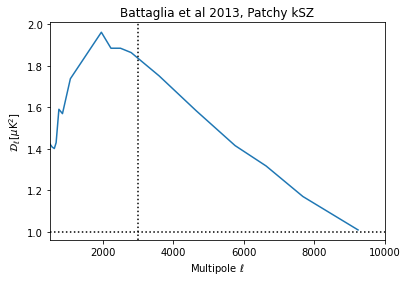

In [8]:
i = 2
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
plt.xlim(500, 10000)
# plt.ylim(0, 15)
# plt.xscale('log')
print(fg_info[k])
plt.axvline(3000, color='k', ls=':')
plt.axhline(1., color='k', ls=':')

dl_ksz_hom_AG.dat
13500 13500.0
0 0.0
{'authors': 'Gorce et al. 2020', 'comments': 'Late-time kSZ', 'extrapolated': False, 'filetype': '.dat', 'freq': None, 'lmax': 13500, 'lmin': 0, 'reference': 'https://ui.adsabs.harvard.edu/abs/2020A%26A...640A..90G/abstract', 'type': 'kSZ', 'typebis': 'Homogeneous kSZ', 'used_in': None, 'website': 'https://szdb.osups.universite-paris-saclay.fr', 'normalised': 3000, 'from': 'theory'}


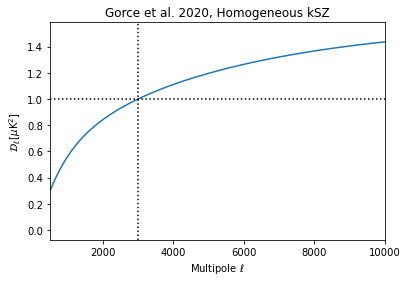

In [9]:
i = 3
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
plt.xlim(500, 10000)
# plt.ylim(0, 15)
# plt.xscale('log')
print(fg_info[k])
plt.axvline(3000, color='k', ls=':')
plt.axhline(1., color='k', ls=':')

dl_ksz_patchy_AG.dat
14999 14999.0
1 1.0
{'authors': 'Gorce et al. 2020', 'comments': 'Patchy kSZ', 'extrapolated': False, 'filetype': '.dat', 'freq': None, 'lmax': 14999, 'lmin': 1, 'reference': 'https://ui.adsabs.harvard.edu/abs/2020A%26A...640A..90G/abstract', 'type': 'kSZ', 'typebis': 'Patchy kSZ', 'used_in': None, 'website': 'https://szdb.osups.universite-paris-saclay.fr', 'normalised': 3000, 'from': 'theory'}


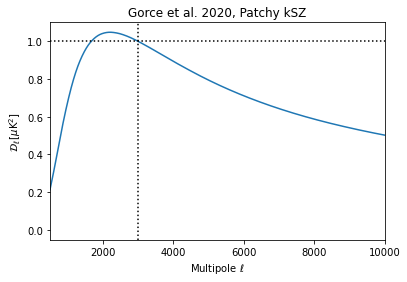

In [10]:
i = 4
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
plt.xlim(500, 10000)
# plt.ylim(0, 15)
# plt.xscale('log')
print(fg_info[k])
plt.axvline(3000, color='k', ls=':')
plt.axhline(1., color='k', ls=':')

dl_ksz_CSFplusPATCHY_13sep2011_norm1_fake25000.txt
13500 25000.0
0 0.0
{'authors': 'Shaw et al. 2012', 'comments': None, 'extrapolated': True, 'filetype': '.txt', 'freq': None, 'lmax': 13500, 'lmin': 0, 'reference': 'https://ui.adsabs.harvard.edu/abs/2012ApJ...756...15S/abstract', 'type': 'kSZ', 'typebis': 'Homogeneous kSZ', 'used_in': 'SPT', 'website': None, 'normalised': 3000, 'from': 'simulations'}


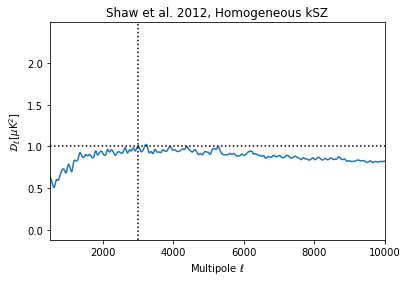

In [11]:
i = 5
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
plt.xlim(500, 10000)
# plt.ylim(0, 15)
# plt.xscale('log')
print(fg_info[k])

plt.axvline(3000, color='k', ls=':')
plt.axhline(1., color='k', ls=':')

dl_ksz_bat.dat
10000 10000.0
2 2.0
{'authors': 'Battaglia et al 2013 + Shaw et al. 2012', 'comments': 'Unidentified, possibly Battaglia et al 2013 + Shaw et al. 2012 but does not really look like it. Identical to dl_ksz_150_bat_norm3000.dat except it is not normalised.', 'extrapolated': False, 'filetype': '.dat', 'freq': None, 'lmax': 10000, 'lmin': 2, 'reference': 'https://ui.adsabs.harvard.edu/abs/2013ApJ...776...83B/abstract', 'type': 'kSZ', 'typebis': 'Total kSZ', 'from': 'simulations', 'used_in': 'SPT', 'website': None, 'normalised': 0}


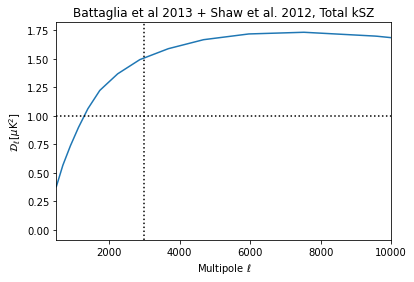

In [12]:
i = 6
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
plt.xlim(500, 10000)
# plt.ylim(0, 15)
# plt.xscale('log')
print(fg_info[k])

plt.axvline(3000, color='k', ls=':')
plt.axhline(1., color='k', ls=':')

dl_ksz_bat_13500.dat
13500 13500.0
2 2.0
{'authors': 'Battaglia', 'comments': 'Unidentified, possibly Battaglia et al 2013 + Shaw et al. 2012 but does not really look like it. Identical to dl_ksz_150_bat_norm3000.dat except it extrapolated to 13500.', 'extrapolated': True, 'filetype': '.dat', 'freq': None, 'lmax': 13500, 'lmin': 2, 'reference': 'https://ui.adsabs.harvard.edu/abs/2013ApJ...776...83B/abstract', 'type': 'kSZ', 'typebis': 'Total kSZ', 'used_in': 'SPT', 'website': None, 'normalised': 3000}


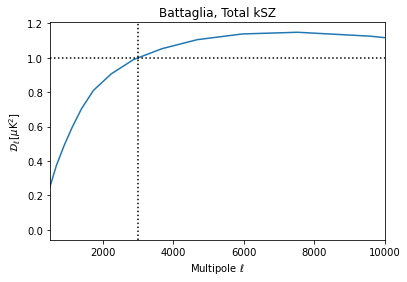

In [13]:
i = 7
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
plt.xlim(500, 10000)
# plt.ylim(0, 15)
# plt.xscale('log')
print(fg_info[k])

plt.axvline(3000, color='k', ls=':')
plt.axhline(1., color='k', ls=':')

dl_ksz_oz_patchy_nolowell_20110708_norm1_fake25000.txt
25000 25000.0
0 0.0
{'authors': 'Zhan et al 2012', 'comments': 'Semi-numerical simulations with excursion set, efficiency of ζ = 20, zre=7.5, Delta_z=4, rmax=5Mpc/h', 'extrapolated': True, 'filetype': '.txt', 'freq': None, 'lmax': 25000, 'lmin': 0, 'reference': 'https://ui.adsabs.harvard.edu/abs/2012ApJ...756...65Z/abstract', 'type': 'kSZ', 'typebis': 'Patchy kSZ', 'used_in': 'SPT', 'website': None, 'from': 'simulations', 'normalised': 3000}


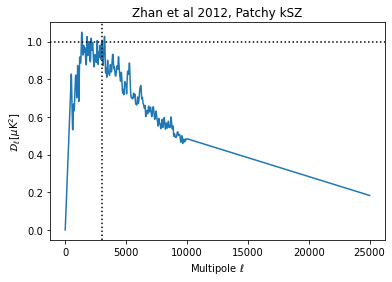

In [14]:
i = 8
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
# plt.xlim(500, 10000)
# plt.ylim(0, 15)
# plt.xscale('log')
print(fg_info[k])

plt.axvline(3000, color='k', ls=':')
plt.axhline(1., color='k', ls=':')

ksz_Alvarez_patchy_10_05.csv
3314 3314.57
302 302.276
{'authors': 'Alvare et al. 2016', 'comments': 'Instantaneous tanh reionisation with tau=0.1', 'extrapolated': False, 'filetype': '.csv', 'freq': None, 'lmax': 3314, 'lmin': 302, 'reference': '', 'type': 'kSZ', 'typebis': 'Patchy kSZ', 'used_in': None, 'website': None, 'normalised': 0, 'from': 'simulations'}


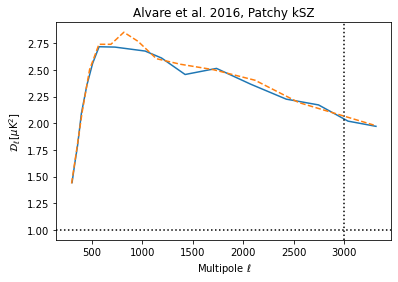

In [15]:
i = 9
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
# plt.xlim(500, 10000)
# plt.ylim(0, 15)
# plt.xscale('log')
print(fg_info[k])

plt.axvline(3000, color='k', ls=':')
plt.axhline(1., color='k', ls=':')

ells2, cls2 = np.loadtxt(fgfolder+'dl_ksz_patchy_alvarez.dat', unpack=True)
plt.plot(ells2, cls2, ls='--')


ksz_Iliev_patchy_13_div2726.csv
42157 42157.8
995 995.049
{'authors': 'Iliev et al. 2007, instant.', 'comments': 'Instant reionisation at z=13, same tau as f250.', 'extrapolated': False, 'filetype': '.csv', 'freq': None, 'lmax': 42157, 'lmin': 995, 'reference': 'https://iopscience.iop.org/article/10.1086/513687', 'type': 'kSZ', 'typebis': 'Patchy kSZ', 'used_in': None, 'website': '', 'normalised': 0, 'from': 'simulations'}


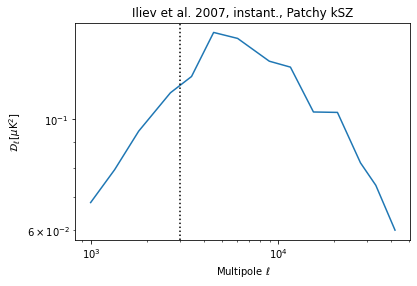

In [16]:
i = 10
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
# plt.xlim(100, 13500)
# plt.ylim(bottom=0)
plt.xscale('log')
plt.yscale('log')
print(fg_info[k])

plt.axvline(3000, color='k', ls=':')
# plt.axhline(1., color='k', ls=':')



dl_ksz_patchy_iliev_f250.dat
41673 41673.79141743729
961 961.3393342932985
{'authors': 'Iliev et al. 2007 f250', 'comments': 'Physical reionisation with low photon production efficiency sources.', 'extrapolated': False, 'filetype': '.dat', 'freq': None, 'lmax': 41673, 'lmin': 961, 'reference': 'https://iopscience.iop.org/article/10.1086/513687', 'type': 'kSZ', 'typebis': 'Patchy kSZ', 'used_in': None, 'website': '', 'normalised': 0, 'from': 'simulations'}


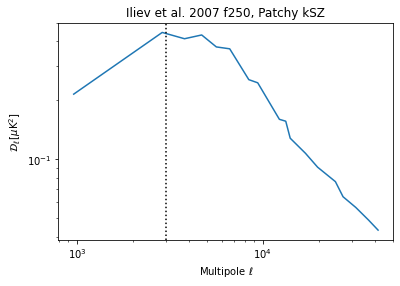

In [17]:
i = 11
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
# plt.xlim(100, 13500)
# plt.ylim(bottom=0)
plt.xscale('log')
plt.yscale('log')
print(fg_info[k])

plt.axvline(3000, color='k', ls=':')
# plt.axhline(1., color='k', ls=':')



ksz_Mmcquin_patchy_10_div2726.csv
18918 18918.9
1029 1029.88
{'authors': 'McQuinn et al. 2005', 'comments': "From Furlanetto's analytical model. Note: paper provides Dls with unit 1.", 'extrapolated': False, 'filetype': '.csv', 'freq': None, 'lmax': 18918, 'lmin': 1029, 'reference': 'https://iopscience.iop.org/article/10.1086/432049', 'type': 'kSZ', 'typebis': 'Patchy kSZ', 'used_in': None, 'website': '', 'normalised': 0, 'from': 'theory'}


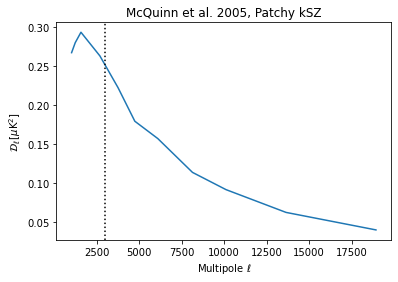

In [18]:
i = 12
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
# plt.xlim(100, 13500)
# plt.ylim(bottom=0)
# plt.xscale('log')
# plt.yscale('log')
print(fg_info[k])

plt.axvline(3000, color='k', ls=':')
# plt.axhline(1., color='k', ls=':')



In [19]:
i = 13
k = ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(f"{fg_info[k]['authors']}, {fg_info[k]['typebis']}")
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
# plt.xlim(100, 13500)
# plt.ylim(bottom=0)
# plt.xscale('log')
# plt.yscale('log')
print(fg_info[k])

plt.axvline(3000, color='k', ls=':')
# plt.axhline(1., color='k', ls=':')



IndexError: list index out of range